# Домашнее задание "Извлечение сущностей и событий из набора текстов"

## Цель

- Извлечь структуры: PERSON, ORG, LOC, EVENT, DATE, IMPACT, SOURCE

- Сравнить подходы:

1) Специализированный NER (token classification) как быстрый baseline

2) LLM IE: промпт + строгий JSON response-schema

- Оптимизировать инференс: batching, quantized vs full precision

- Получить метрики:

1) prefill_time, decode_1step_time, TTFT≈prefill+decode

2) latency, throughput (tokens/sec, samples/sec)

3) VRAM/RAM, JSON-valid rate, agreement P/R/F1 с NER-baseline

Используется открытый датасет [Gazeta от IlyaGusev](https://huggingface.co/datasets/IlyaGusev/gazeta).

Он содержит ~74k новостных статей на русском языке с краткими эталонными саммари, составленными журналистами:

> Texts and summaries were written by journalists at Gazeta.



Каждая запись включает:

text: полный текст новости

summary: короткое резюме новости

title: заголовок статьи;

date: дата публикации;

url: ссылка на статью.

Полный текст новости из датасета будем использовать для извлечения сущностей.

## Установка зависимостей

In [2]:
!pip -q install -U datasets transformers accelerate bitsandbytes
!pip -q install -U tqdm psutil pynvml
!pip -q install -U pydantic jsonschema rapidfuzz orjson

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 166.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 145.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.


In [3]:
import os, re, json, time, math, random
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForTokenClassification,
    pipeline,
    BitsAndBytesConfig,
)

from pydantic import BaseModel, Field
from typing import List, Optional, Literal, Dict, Any, Tuple
from jsonschema import validate as js_validate, ValidationError
from rapidfuzz import fuzz

# GPU info
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM total (GB):", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 2))

print("RAM total (GB):", round(psutil.virtual_memory().total/1024**3, 2))

device: cuda
GPU: NVIDIA H100 80GB HBM3
VRAM total (GB): 79.18
RAM total (GB): 230.05


In [4]:
!nvidia-smi

Sun Mar  1 15:09:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   27C    P0             68W /  700W |       4MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Загрузка датасета

In [5]:
ds = load_dataset("IlyaGusev/gazeta")

print(ds)
print("splits:", list(ds.keys()))
print("columns:", ds["train"].column_names)

sample_df = pd.DataFrame(ds["train"].select(range(5)))
sample_df

README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 60964
    })
    validation: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 6369
    })
    test: Dataset({
        features: ['text', 'summary', 'title', 'date', 'url'],
        num_rows: 6793
    })
})
splits: ['train', 'validation', 'test']
columns: ['text', 'summary', 'title', 'date', 'url']


,text,summary,title,date,url
0,Сегодня транспортный налог начисляется в завис...,С 2011 года правительство отменяет самый раздр...,Налог в бак,2010-06-01 10:35:49,https://www.gazeta.ru/auto/2010/05/31_a_337771...
1,Словосочетание «музыкальный кинофестиваль» уже...,"Британские затворники, московские модники, бра...","Секс, наркотики и темный зал",2010-06-01 10:42:59,https://www.gazeta.ru/culture/2010/06/01/a_337...
2,После более чем 12-часовых консультаций Совет ...,Совбез ООН собрался на экстренное совещание дл...,Осудить и отпустить,2010-06-01 11:00:30,https://www.gazeta.ru/politics/2010/06/01_a_33...
3,"Жертвами урагана «Агата», обрушившегося на Цен...",Ураган «Агата» в Центральной Америке унес жизн...,«Агата» открыла страшный сезон,2010-06-01 11:05:30,https://www.gazeta.ru/social/2010/06/01/337799...
4,Решение ограничить рост тарифов естественных м...,Правительство хочет сдержать рост тарифов есте...,Тарифы инфляцию не остановят,2010-06-01 11:48:50,https://www.gazeta.ru/financial/2010/06/01/337...


In [6]:
def add_lengths(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["len_text"] = out["text"].str.len()
    out["len_summary"] = out["summary"].str.len()
    out["len_title"] = out["title"].str.len()
    return out

stats_df = pd.DataFrame(ds["train"].select(range(5000)))
stats_df = add_lengths(stats_df)

stats = stats_df[["len_text", "len_summary", "len_title"]].describe(
    percentiles=[.5, .75, .9, .99]
).round(2)

stats

,len_text,len_summary,len_title
count,5000.00,5000.00,5000.00
mean,4152.52,277.53,26.50
std,1255.80,71.21,7.71
min,324.00,76.00,6.00
50%,3946.00,276.00,26.00
75%,4853.00,324.00,31.00
90%,5875.10,371.00,36.00
99%,7824.21,454.01,47.00
max,9168.00,560.00,68.00


**Для иллюстрации пайплайна в условиях ограниченности ресурсов будем делать NER на саммари новостей с заголовками вместо полного текста.**

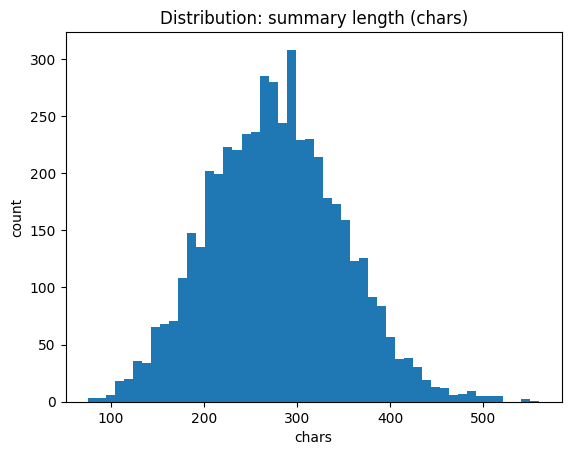

In [7]:
plt.figure()
plt.hist(stats_df["len_summary"], bins=50)
plt.title("Distribution: summary length (chars)")
plt.xlabel("chars"); plt.ylabel("count")
plt.show()

## Dataset Split

In [8]:
N_DEMO = 200
N_BENCH = 1000
N_EVAL = 1000

train = ds["train"]

def make_subset(split, n, seed=SEED):
    n = min(n, len(split))
    idx = np.random.RandomState(seed).choice(len(split), size=n, replace=False)
    return split.select(idx.tolist())

demo_set = make_subset(train, N_DEMO, seed=SEED)
bench_set = make_subset(train, N_BENCH, seed=SEED+1)
eval_set = make_subset(train, N_EVAL, seed=SEED+2)

print(len(demo_set), len(bench_set), len(eval_set))

200 1000 1000


## Пайплайн NER. Загрузка ner-rubert-tiny-news

https://huggingface.co/r1char9/ner-rubert-tiny-news

- PER	Persons
- ORG	Organizations
- LOC	Locations
- GEOPOLIT	Geopolitical entities (countries, regions)
- MEDIA	Media outlets and resources

In [9]:
NER_MODEL_ID = "r1char9/ner-rubert-tiny-news"

ner_tok = AutoTokenizer.from_pretrained(NER_MODEL_ID)
ner_model = AutoModelForTokenClassification.from_pretrained(NER_MODEL_ID)

ner_pipe = pipeline(
    "ner",
    model=ner_model,
    tokenizer=ner_tok,
    aggregation_strategy="simple",
    device=0 if device=="cuda" else -1
)

test_text = "Герман Греф заявил в Москве, что Сбербанк сотрудничает с Яндексом, сообщает РИА Новости."
ner_pipe(test_text)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/116M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: r1char9/ner-rubert-tiny-news
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

[{'entity_group': 'PER',
  'score': np.float32(0.99495125),
  'word': 'Герман Греф',
  'start': 0,
  'end': 11},
 {'entity_group': 'LOC',
  'score': np.float32(0.9530206),
  'word': 'Москве',
  'start': 21,
  'end': 27},
 {'entity_group': 'ORG',
  'score': np.float32(0.9945608),
  'word': 'Сбербанк',
  'start': 33,
  'end': 41},
 {'entity_group': 'ORG',
  'score': np.float32(0.93905723),
  'word': 'Яндексом',
  'start': 57,
  'end': 65},
 {'entity_group': 'MEDIA',
  'score': np.float32(0.8616751),
  'word': 'РИА Новости.',
  'start': 76,
  'end': 88}]

## Маппинг полей и доп. обработка (леммматизация, дедупликация)

In [10]:
!pip -q install -U pymorphy3

import re, json
from functools import lru_cache
from typing import Dict, List, Literal, Optional, Tuple

from pymorphy3 import MorphAnalyzer

morph = MorphAnalyzer()

# слова/числа (с дефисами)
WORD_RE = re.compile(r"[A-Za-zА-Яа-яЁё]+(?:-[A-Za-zА-Яа-яЁё]+)*|\d+")

@lru_cache(maxsize=200_000)
def lemma_token(tok: str) -> str:
    tok = tok.lower()
    if tok.isdigit():
        return tok
    return morph.parse(tok)[0].normal_form

def lemmatize_phrase(text: str) -> str:
    toks = WORD_RE.findall(str(text))
    return " ".join(lemma_token(t) for t in toks).strip()

def try_parse_json(s: str) -> Optional[dict]:
    s = str(s).strip()
    s = re.sub(r"^```(?:json)?\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s*```$", "", s)
    first, last = s.find("{"), s.rfind("}")
    if first != -1 and last != -1 and last > first:
        s = s[first:last+1]
    try:
        return json.loads(s)
    except Exception:
        return None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 103.0 MB/s eta 0:00:00


In [11]:
from pydantic import BaseModel, Field, ValidationError, ConfigDict

NERLabel = Literal["PERSON","ORG","LOC","GEOPOLIT","MEDIA","EVENT","DATE","IMPACT","SOURCE"]

class NerItem(BaseModel):
    model_config = ConfigDict(extra="ignore")
    text: str
    lemma: str

class NerResult(BaseModel):
    model_config = ConfigDict(extra="ignore")

    PERSON:   List[NerItem] = Field(default_factory=list)
    ORG:      List[NerItem] = Field(default_factory=list)
    LOC:      List[NerItem] = Field(default_factory=list)
    GEOPOLIT: List[NerItem] = Field(default_factory=list)
    MEDIA:    List[NerItem] = Field(default_factory=list)
    EVENT:    List[NerItem] = Field(default_factory=list)
    DATE:     List[NerItem] = Field(default_factory=list)
    IMPACT:   List[NerItem] = Field(default_factory=list)
    SOURCE:   List[NerItem] = Field(default_factory=list)

def dedup_result(res: NerResult) -> NerResult:
    # дедуп по lemma внутри каждого класса
    for label in res.model_fields.keys():
        seen = set()
        uniq = []
        for item in getattr(res, label):
            if item.lemma and item.lemma not in seen:
                seen.add(item.lemma)
                uniq.append(item)
        setattr(res, label, uniq)
    return res

def validate_and_fix(obj: dict) -> Tuple[bool, Optional[dict], Optional[str]]:
    try:
        res = NerResult.model_validate(obj)

        # на всякий случай: если lemma пустая/не пришла — досчитаем
        for label in res.model_fields.keys():
            fixed = []
            for it in getattr(res, label):
                txt = (it.text or "").strip()
                lem = (it.lemma or "").strip()
                if not txt:
                    continue
                if not lem:
                    lem = lemmatize_phrase(txt)
                fixed.append(NerItem(text=txt, lemma=lem))
            setattr(res, label, fixed)

        res = dedup_result(res)
        return True, res.model_dump(), None

    except ValidationError as e:
        return False, None, str(e)[:600]

In [12]:
def llm_json_to_nerresult(obj: dict) -> tuple[bool, dict | None, str | None]:
    """
    LLM возвращает: {LABEL: [str, str, ...], ...}
    Приводим к NerResult: {LABEL: [{"text":..,"lemma":..}, ...], ...}
    """
    if not isinstance(obj, dict):
        return False, None, "LLM output is not a dict"

    fixed = {}
    for label in NerResult.model_fields.keys():
        vals = obj.get(label, [])
        if vals is None:
            vals = []
        if not isinstance(vals, list):
            vals = [vals]

        items = []
        for v in vals:
            txt = str(v).strip()
            if not txt:
                continue
            items.append({"text": txt, "lemma": lemmatize_phrase(txt)})

        fixed[label] = items

    try:
        res = NerResult.model_validate(fixed)
        res = dedup_result(res)
        return True, res.model_dump(), None
    except ValidationError as e:
        return False, None, str(e)[:600]

In [13]:
# mapping по model card: PER/ORG/LOC/GEOPOLIT/MEDIA
NER_MAP = {
    "PER": "PERSON",
    "ORG": "ORG",
    "LOC": "LOC",
    "GEOPOLIT": "GEOPOLIT",
    "MEDIA": "MEDIA",
}

def ner_special_to_nerresult(text: str) -> dict:
    fixed = {k: [] for k in NerResult.model_fields.keys()}

    for e in ner_pipe(text):
        src = e.get("entity_group")
        if src not in NER_MAP:
            continue
        label = NER_MAP[src]
        txt = str(e.get("word", "")).strip()
        if not txt:
            continue
        fixed[label].append({"text": txt, "lemma": lemmatize_phrase(txt)})

    res = NerResult.model_validate(fixed)
    res = dedup_result(res)
    return res.model_dump()

## EVAL — сравнение LLM vs NER по lemma (precision/recall/F1)

In [14]:
def as_lemma_set(ner_res: dict, label: str) -> set[str]:
    items = ner_res.get(label, []) or []
    return {str(it.get("lemma","")).strip() for it in items if it.get("lemma")}

def prf(tp, fp, fn):
    p = tp / (tp + fp + 1e-9)
    r = tp / (tp + fn + 1e-9)
    f = 2*p*r / (p + r + 1e-9)
    return p, r, f

def eval_llm_vs_special(tok, model, dataset, n=200, batch_size=4, max_new_tokens=256):
    labels = list(NerResult.model_fields.keys())

    rows = []
    items = [dataset[i] for i in range(min(n, len(dataset)))]

    for i in tqdm(range(0, len(items), batch_size)):
        batch = items[i:i+batch_size]
        pack = llm_ner_batch(tok, model, batch, max_new_tokens=max_new_tokens)

        for rec, out in zip(batch, pack["items"]):
            text = f"{rec['title']}\n\n{rec['summary']}"
            gold = ner_special_to_nerresult(text)  # спец-NER

            pred = out["result"] if out["json_ok"] else {k: [] for k in labels}

            for lab in labels:
                pset = as_lemma_set(pred, lab)
                gset = as_lemma_set(gold, lab)

                tp = len(pset & gset)
                fp = len(pset - gset)
                fn = len(gset - pset)
                p, r, f = prf(tp, fp, fn)

                rows.append({"label": lab, "tp": tp, "fp": fp, "fn": fn, "precision": p, "recall": r, "f1": f})

    df = pd.DataFrame(rows).groupby("label")[["tp","fp","fn"]].sum().reset_index()
    df["precision"], df["recall"], df["f1"] = zip(*df.apply(lambda x: prf(x.tp, x.fp, x.fn), axis=1))
    df = df.sort_values("f1", ascending=False).reset_index(drop=True)

    macro_f1 = float(df["f1"].mean())
    return df, macro_f1

## Промпт для базовой LLM

In [15]:
LABELS = ["PERSON","ORG","LOC","GEOPOLIT","MEDIA","EVENT","DATE","IMPACT","SOURCE"]

SCHEMA_HINT = f"""
Верни СТРОГО валидный JSON без markdown и без текста вокруг.

Формат — один объект с фиксированными ключами:
{", ".join(LABELS)}

Значение каждого ключа — список строк (упоминания сущностей как в тексте).
Если сущностей типа нет — верни пустой список.

Кратко про типы (всё извлечение — только из текста):
PERSON — люди;
ORG — организации;
LOC — места/объекты;
GEOPOLIT — страны/регионы/гос-образования;
MEDIA — СМИ/медиа-ресурсы;
EVENT — названные события;
DATE — даты/периоды;
IMPACT — последствия (жертвы/ущерб/санкции/рост-падение/эвакуация и т.п.);
SOURCE — источник сообщения (“по данным…”, “сообщает…”, “заявил…”, “в пресс-службе…”).
Отвечай ТОЛЬКО этим JSON-объектом и не добавляй никаких других ключей.
"""

SYSTEM_PROMPT = "Ты — система NER для русских новостей. Отвечай только валидным JSON по схеме."

def build_prompt(title: str, text: str) -> str:
    max_chars = 8000
    text_cut = str(text)[:max_chars]
    return f"""{SCHEMA_HINT}

Заголовок:
{title}

Текст новости:
{text_cut}
"""

## Загрузка LLM Qwen2.5-7B-Instruct (quantized vs bf16)

In [16]:
LLM_ID = "Qwen/Qwen2.5-7B-Instruct"

def load_llm_quant4(model_id=LLM_ID):
    qconf = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=qconf,
        device_map="auto",
        torch_dtype=torch.bfloat16,
    )
    return tok, model

def load_llm_bf16(model_id=LLM_ID):
    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        torch_dtype=torch.bfloat16,
    )
    return tok, model


llm_tok_q4, llm_model_q4 = None, None
try:
    llm_tok_q4, llm_model_q4 = load_llm_quant4()
    print("nf4 model loaded OK")
except Exception as e:
    print("nf4 model load failed")
    print(type(e), str(e)[:200])


llm_tok_bf16, llm_model_bf16 = None, None
try:
    llm_tok_bf16, llm_model_bf16 = load_llm_bf16()
    print("BF16 model loaded OK")
except Exception as e:
    print("BF16 model load failed (likely OOM). We'll continue with Q4 only.")
    print(type(e), str(e)[:200])

llm_tok_q4.padding_side = "left"
if llm_tok_q4.pad_token is None:
    llm_tok_q4.pad_token = llm_tok_q4.eos_token

if llm_tok_bf16 is not None:
    llm_tok_bf16.padding_side = "left"
    if llm_tok_bf16.pad_token is None:
        llm_tok_bf16.pad_token = llm_tok_bf16.eos_token

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

nf4 model loaded OK


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

BF16 model loaded OK


## Инференс для LLM

In [17]:
import time
import torch

@torch.inference_mode()
def llm_ner_one(tok, model, rec: dict, max_new_tokens: int = 256) -> dict:
    prompt = build_prompt(rec["title"], rec["summary"])
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    chat = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(chat, return_tensors="pt").to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    out_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        eos_token_id=tok.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    gen_ids = out_ids[0, inputs["input_ids"].shape[1]:]
    raw = tok.decode(gen_ids, skip_special_tokens=True)

    obj = try_parse_json(raw)
    ok, result, err = (False, None, "JSON parse failed")
    if obj is not None:
        ok, result, err = llm_json_to_nerresult(obj)

    return {
        "json_ok": ok,
        "result": result,
        "err": err,
        "latency_s": t1 - t0,
        "raw_head": raw[:400],
    }

In [18]:
@torch.inference_mode()
def llm_ner_batch(tok, model, records: list[dict], max_new_tokens: int = 256) -> dict:
    prompts = []
    for r in records:
        p = build_prompt(r["title"], r["summary"])
        msgs = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": p}]
        prompts.append(tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True))

    inputs = tok(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    out_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        eos_token_id=tok.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    items = []
    for i in range(len(records)):
        in_len = int((inputs["attention_mask"][i] == 1).sum().item())
        gen_ids = out_ids[i, in_len:]
        raw = tok.decode(gen_ids, skip_special_tokens=True)

        obj = try_parse_json(raw)
        ok, result, err = (False, None, "JSON parse failed")
        if obj is not None:
            ok, result, err = llm_json_to_nerresult(obj)

        items.append({
            "json_ok": ok,
            "result": result,
            "err": err,
            "raw_head": raw[:250],
        })

    return {"batch_latency_s": (t1 - t0), "items": items}

In [21]:
# 1) выбираем один пример
rec = eval_set[2]  # или eval_set[0]
text = f"{rec['title']}\n\n{rec['summary']}"
print("text:", text)

# 2) спец-NER
gold = ner_special_to_nerresult(text)

# 3) LLM NER
pred_out = llm_ner_one(llm_tok_q4, llm_model_q4, rec, max_new_tokens=2048)
pred = pred_out["result"] if pred_out["json_ok"] else {k: [] for k in NerResult.model_fields.keys()}

print("LLM json_ok:", pred_out["json_ok"], "latency_s:", round(pred_out["latency_s"], 3))
if not pred_out["json_ok"]:
    print("ERR:", pred_out["err"])
    print("RAW(head):", pred_out["raw_head"])

def count_items(d):
    return {k: len(d.get(k, [])) for k in NerResult.model_fields.keys()}

print("\nCounts (special NER):", count_items(gold))
print("Counts (LLM):        ", count_items(pred))

for lab in ["PERSON","ORG","LOC","GEOPOLIT","MEDIA","EVENT","DATE","IMPACT","SOURCE"]:
    g = [x["text"] for x in gold.get(lab, [])][:3]
    p = [x["text"] for x in pred.get(lab, [])][:3]
    print(f"{lab:9} | gold: {g} | pred: {p}")

text: Конкурент за $40 млрд

Парламент Никарагуа одобрил строительство канала между Тихим и Атлантическим океаном — конкурента Панамского — общей стоимостью $40 млрд. Подрядчиком выбрана малоизвестная китайская компания. Строительство канала позволит удвоить ВВП страны и побороть безработицу, говорят сторонники строительства. Проект нарушит экологию и будет экономически нерентабелен, возражают оппозиция и экологи.


/tmp/ipython-input-672/1143166694.py:25: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  for label in res.model_fields.keys():


LLM json_ok: True latency_s: 4.187

Counts (special NER): {'PERSON': 0, 'ORG': 0, 'LOC': 2, 'GEOPOLIT': 2, 'MEDIA': 0, 'EVENT': 0, 'DATE': 0, 'IMPACT': 0, 'SOURCE': 0}
Counts (LLM):         {'PERSON': 0, 'ORG': 2, 'LOC': 4, 'GEOPOLIT': 1, 'MEDIA': 0, 'EVENT': 1, 'DATE': 0, 'IMPACT': 4, 'SOURCE': 0}
PERSON    | gold: [] | pred: []
ORG       | gold: [] | pred: ['Парламент Никарагуа', 'малоизвестная китайская компания']
LOC       | gold: ['Тихим и Атлантическим океаном', '##ского'] | pred: ['Никарагуа', 'Тихий океан', 'Атлантический океан']
GEOPOLIT  | gold: ['Никарагуа', 'Панам'] | pred: ['Никарагуа']
MEDIA     | gold: [] | pred: []
EVENT     | gold: [] | pred: ['строительство канала']
DATE      | gold: [] | pred: []
IMPACT    | gold: [] | pred: ['удвоить ВВП страны', 'побороть безработицу', 'нарушит экологию']
SOURCE    | gold: [] | pred: []


## Оценка метрик

### llm vs ner

In [22]:
df_scores, macro_f1 = eval_llm_vs_special(
    llm_tok_q4, llm_model_q4,
    eval_set,
    n=1000,
    batch_size=32,
    max_new_tokens=1024
)

  0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipython-input-672/1143166694.py:25: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  for label in res.model_fields.keys():
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [23]:
print("Macro-F1:", round(macro_f1, 4))
df_scores

Macro-F1: 0.2071


,label,tp,fp,fn,precision,recall,f1
0,PERSON,787,254,994,0.756004,0.441887,0.557760
1,LOC,488,443,832,0.524168,0.369697,0.433585
2,ORG,636,768,1394,0.452991,0.313300,0.370414
3,GEOPOLIT,200,363,333,0.355240,0.375235,0.364964
4,MEDIA,10,78,48,0.113636,0.172414,0.136986
5,DATE,0,189,0,0.000000,0.000000,0.000000
6,EVENT,0,1878,0,0.000000,0.000000,0.000000
7,IMPACT,0,336,0,0.000000,0.000000,0.000000
8,SOURCE,0,96,0,0.000000,0.000000,0.000000


Это не 100% точность NER, тк у датасета нет ручной разметки: сравниваем LLM с ответами NER.

**Поэтому результаты интерпретируем как: насколько LLM согласуется с проф. NER-моделью на тех же данных.**

Для устойчивого сравнения приводим каждую сущность к лемме (lemma) и сравниваем множества лемм по каждому классу (дубликаты не учитываются).

Также приводим метки классов к общей схеме.


Для каждого класса (например, ORG) считаем:

- TP (true positives): леммы, которые есть и у LLM, и у NER

- FP (false positives): леммы, которые LLM выдал, но спец-NER не нашёл

- FN (false negatives): леммы, которые спец-NER нашёл, но LLM не выдал

- Precision = TP / (TP + FP) — насколько чистые предсказания (меньше лишнего).

- Recall = TP / (TP + FN) — насколько хорошо модель находит всё (покрытие).

- F1 = 2·P·R / (P + R) — гармоническое среднее precision и recall.

Метрики считаются по каждому классу, затем берётся Macro-F1 — среднее F1 по классам без учёта дисбаланса (все классы равноважны).

**Выводы:**
- границы сущности у спец-NER хуже, чем у LLM - может включить лишнее и потерять нужное.
- LLM перефразирует смысловые куски в EVENT

Метрики могут страдать из-за:
- метрика по точному совпадению лемм может не засчитать
- разные границы (полное имя vs часть имени)
- разные способы записи
- синонимы/перефразирование (LLM иногда переформулирует)

Метрики по прогону 1000 примеров:
- Macro-F1 = 0.207. Специализированная NER-модель не извлекает метки DATE/EVENT/IMPACT/SOURCE. Поэтому для этих классов у gold фактически пусто, и любая попытка LLM извлекать их превращается в FP, а F1 становится 0. Это "наказывает" LLM за занижает Macro-F1.


1) PERSON — F1 = 0.558

- Precision высокий (0.756) → LLM редко выдаёт лишних персон

- Recall заметно ниже (0.442) → LLM часто недоизвлекает людей, которых нашёл спец-NER

2) LOC — F1 = 0.434

- Precision 0.524

- Recall 0.370

Оба показателя средние → LLM и пропускает места, и даёт лишние

3) ORG — F1 = 0.370

- Precision 0.453

- Recall 0.313


4) LLM активно заполняет EVENT переформулировками

5) GEOPOLIT — F1 = 0.365

- Precision 0.355

- Recall 0.375 (примерно баланс)

LLM примерно одинаково ошибается в обе стороны.


**LLM адекватно извлекает PERSON, приемлемо — LOC/ORG/GEOPOLIT, но заметно недобирает recall (много пропусков).**

### quant vs bf16

In [ ]:
def benchmark_comparison(models_configs, dataset, batch_sizes=[1, 2, 4, 8, 16]):
    all_results = []

    for config in models_configs:
        name = config["name"]
        tok = config["tokenizer"]
        model = config["model"]

        if model is None:
            print(f"Skipping {name} (not loaded)")
            continue

        print(f"Benchmarking {name}...")

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        df_res = bench_llm_batches(tok, model, dataset, batch_sizes=batch_sizes, max_new_tokens=128)

        df_res["model"] = name
        df_res["latency_per_sample_s"] = df_res["latency_s"] / df_res["batch_size"]
        df_res["gen_tokens_per_s"] = df_res["tokens_per_s"]
        df_res["ttft_s_avg"] = df_res["latency_s"] / 2

        all_results.append(df_res)

    return pd.concat(all_results, ignore_index=True)

configs = [
    {"name": "Qwen2.5-7B-NF4", "tokenizer": llm_tok_q4, "model": llm_model_q4},
    {"name": "Qwen2.5-7B-BF16", "tokenizer": llm_tok_bf16, "model": llm_model_bf16}
]


In [ ]:
bench_df = benchmark_comparison(configs, bench_set, batch_sizes=(1, 2, 4, 8, 16))
bench_df

Benchmarking Qwen2.5-7B-NF4...
Benchmarking Qwen2.5-7B-BF16...


,batch_size,latency_s,samples_per_s,gen_tokens_total,tokens_per_s,model,latency_per_sample_s,gen_tokens_per_s,ttft_s_avg
0,1,2.419535,0.413302,96,39.677039,Qwen2.5-7B-NF4,2.419535,39.677039,1.209768
1,2,5.163556,0.387330,279,54.032532,Qwen2.5-7B-NF4,2.581778,54.032532,2.581778
2,4,4.930515,0.811274,651,132.034892,Qwen2.5-7B-NF4,1.232629,132.034892,2.465257
3,8,5.162103,1.549756,1486,287.867192,Qwen2.5-7B-NF4,0.645263,287.867192,2.581051
4,16,5.139627,3.113066,3314,644.793818,Qwen2.5-7B-NF4,0.321227,644.793818,2.569814
5,1,1.184110,0.844516,82,69.250327,Qwen2.5-7B-BF16,1.184110,69.250327,0.592055
6,2,2.062060,0.969904,279,135.301582,Qwen2.5-7B-BF16,1.031030,135.301582,1.031030
7,4,2.116546,1.889872,651,307.576652,Qwen2.5-7B-BF16,0.529136,307.576652,1.058273
8,8,2.101502,3.806801,1486,707.113249,Qwen2.5-7B-BF16,0.262688,707.113249,1.050751
9,16,2.434686,6.571689,3314,1361.161158,Qwen2.5-7B-BF16,0.152168,1361.161158,1.217343


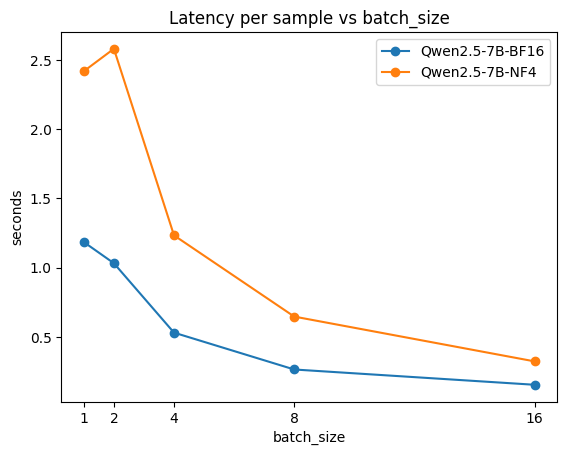

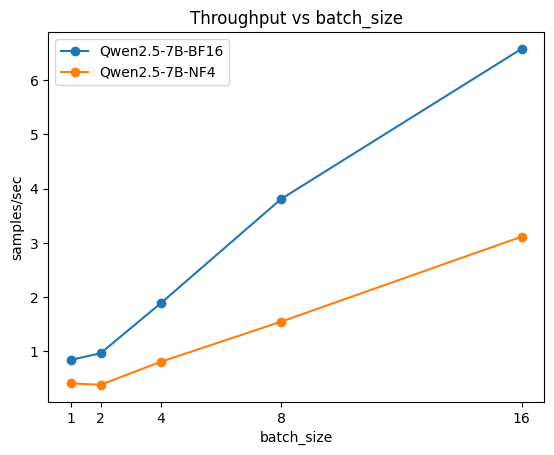

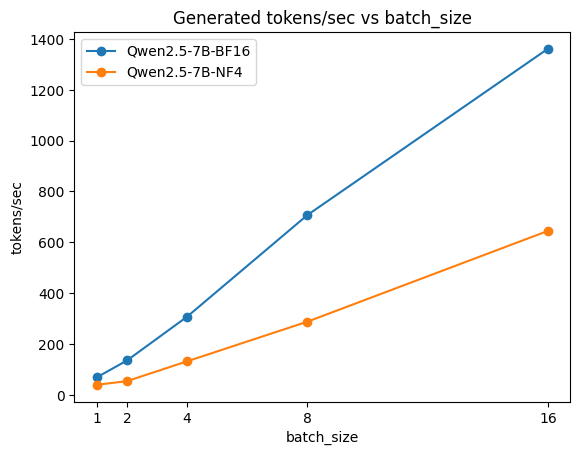

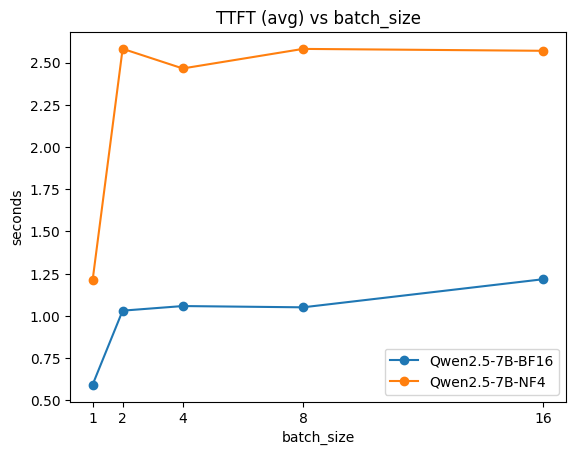

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(df, metric, title, ylabel):
    plt.figure()
    for model_name, g in df.groupby("model"):
        g = g.sort_values("batch_size")
        plt.plot(g["batch_size"], g[metric], marker="o", label=model_name)
    plt.title(title)
    plt.xlabel("batch_size")
    plt.ylabel(ylabel)
    plt.xticks(sorted(df["batch_size"].unique()))
    plt.legend()
    plt.show()

plot_metric(bench_df, "latency_per_sample_s", "Latency per sample vs batch_size", "seconds")
plot_metric(bench_df, "samples_per_s", "Throughput vs batch_size", "samples/sec")
plot_metric(bench_df, "gen_tokens_per_s", "Generated tokens/sec vs batch_size", "tokens/sec")
plot_metric(bench_df, "ttft_s_avg", "TTFT (avg) vs batch_size", "seconds")

**Выводы: BF16 быстрее NF4 на всех batch size**

BF16/FP16 на H200 разгоняются тензорными ядрами до высоких производительностей.

NF4 (bitsandbytes) в основном даёт экономию памяти, а не гарантированный speedup: веса хранятся в 4-бит, но вычисления всё равно идут в 16/32-бит

Эффект batching: throughput растёт, TTFT тоже растёт

У обеих моделей:
- с ростом batch резко растёт samples/sec и tokens/sec (GPU лучше загружена),

- ttft_s_avg растёт (ожидаемо: больше prefill/параллельности, больше работы до первого токена).

### JSON-valid rate (как часто LLM отдаёт валидный JSON)

В этом блоке измеряем надёжность структурированного вывода: насколько часто LLM возвращает ответ, который можно строго распарсить как JSON и провалидировать нашей схемой.

In [ ]:
from tqdm.auto import tqdm

def measure_json_valid_rate(tok, model, dataset, n=200, batch_size=4, max_new_tokens=1024):
    items = [dataset[i] for i in range(min(n, len(dataset)))]
    ok = 0
    total = 0

    for i in tqdm(range(0, len(items), batch_size)):
        batch = items[i:i+batch_size]
        pack = llm_ner_batch(tok, model, batch, max_new_tokens=max_new_tokens)
        for it in pack["items"]:
            total += 1
            ok += int(it["json_ok"])
    return ok / max(total, 1)

json_rate = measure_json_valid_rate(llm_tok_q4, llm_model_q4, eval_set, n=200, batch_size=4, max_new_tokens=256)
print("JSON valid rate:", f"{json_rate:.2%}")

  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipython-input-836/1143166694.py:25: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  for label in res.model_fields.keys():


JSON valid rate: 100.00%


**JSON valid rate: 100.00% - означает, что модель во всех случаях возвращает валидный JSON, пригодный для парсинга и дальнейшей работы**

### LLM: batch size → latency, samples/sec, tokens/sec

Оценка производительности инференса LLM при разных размерах батча.

Как меняется:
- латентность (время одного вызова генерации)

- пропускная способность (сколько примеров/токенов в секунду модель выдаёт)

В пайплайне почти всегда выгодно обрабатывать тексты пакетами (batching), особенно на GPU — так повышается загрузка видеокарты и общий throughput.

Важно найти компромисс: batch size → скорость/задержка.

Эти метрики помогают выбрать оптимальный batch_size.

In [ ]:
import pandas as pd
import time
import torch

@torch.inference_mode()
def llm_ner_batch_perf(tok, model, records, max_new_tokens=1024):

    prompts = []
    for r in records:
        p = build_prompt(r["title"], r["summary"])
        msgs = [{"role":"system","content":SYSTEM_PROMPT},{"role":"user","content":p}]
        prompts.append(tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True))

    inputs = tok(prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    out_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        eos_token_id=tok.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()

    prompt_tokens_total = int(inputs["attention_mask"].sum().item())
    gen_tokens_total = 0
    for i in range(len(records)):
        in_len = int((inputs["attention_mask"][i] == 1).sum().item())
        gen_tokens_total += int((out_ids[i].shape[0] - in_len))

    return {
        "latency_s": (t1 - t0),
        "prompt_tokens_total": prompt_tokens_total,
        "gen_tokens_total": gen_tokens_total,
    }

def bench_llm_batches(tok, model, dataset, batch_sizes=(1,2,4,8,16), max_new_tokens=256):
    base = [dataset[i] for i in range(max(batch_sizes))]
    rows = []
    for bs in batch_sizes:
        recs = base[:bs]
        m = llm_ner_batch_perf(tok, model, recs, max_new_tokens=max_new_tokens)
        lat = m["latency_s"]
        rows.append({
            "batch_size": bs,
            "latency_s": lat,
            "samples_per_s": bs / max(lat, 1e-9),
            "gen_tokens_total": m["gen_tokens_total"],
            "tokens_per_s": m["gen_tokens_total"] / max(lat, 1e-9),
        })
    return pd.DataFrame(rows)


In [ ]:
bench_df = bench_llm_batches(llm_tok_q4, llm_model_q4, bench_set, batch_sizes=(1,2,4,8,16), max_new_tokens=256)
bench_df

,batch_size,latency_s,samples_per_s,gen_tokens_total,tokens_per_s
0,1,2.531893,0.394961,96,37.916297
1,2,5.383818,0.371484,299,55.536792
2,4,5.283930,0.757012,691,130.773867
3,8,6.830831,1.171161,1878,274.929940
4,16,8.130230,1.967964,4370,537.500143


Оценка производительности модели Qwen (4-bit quantized) при извлечении сущностей из новостных summary на GPU NVIDIA H200 при различных размерах батча.
- latency_s — время генерации одного batch;

- samples_per_s — количество обработанных примеров в секунду;

- gen_tokens_total — суммарное число сгенерированных токенов;

- tokens_per_s — скорость генерации токенов (throughput модели).

При увеличении batch size в 16 раз (1 → 16):

- latency выросла только в **~3.2 раза**

- при этом обработка примеров выросла почти в **5 раз**

**Вывод: GPU используется значительно эффективнее при батчинге.**